# Exploração — macro BR mensal (BCB/SGS)Objetivo: conhecer as **variáveis de controle macroeconômicas** que entram no modelo — o que cadacoluna mede, em que unidade, com que cobertura, e o que já dá para ver na série antes de modelar.Fonte: `data/interim/parquet/macro_br_mes.parquet`, produzido por[04_bcb_sgs.py](../src/coleta/T-012_T-013/04_bcb_sgs.py) — ticket[T-013](../tickets/01-coleta/T-013-bcb-sgs.md).## A pergunta que este notebook responde> *O que tem nesse arquivo, e dá para confiar nele?*São 8 colunas e uma linha por mês, **nacionais** — não há recorte por UF. No T-024 elas sãoreplicadas para todas as UFs do mesmo mês, ou seja: **elas explicam variação no tempo, nuncadiferença entre estados**. Isso é uma limitação estrutural do dado, não uma escolha de recorte.O notebook percorre: schema e tipos (1), cobertura temporal e nulos (2), o que cada variávelsignifica e sua distribuição (3), o comportamento no tempo (4), correlações (5) e umaconferência contra valores publicados (6).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CAMINHO = Path("..") / "data" / "interim" / "parquet" / "macro_br_mes.parquet"

df = pd.read_parquet(CAMINHO)
print(f"{len(df):,} linhas x {df.shape[1]} colunas")
df.head()

151 linhas x 8 colunas


,ano_mes,dolar_ptax_medio,dolar_ptax_fim,ipca_mm,ipca_indice_base,selic,selic_efetiva_am,igpm
0,2014-01-01,2.382209,2.4263,0.55,93.337727,10.5,0.849344,0.48
1,2014-02-01,2.38368,2.3334,0.69,93.981758,10.75,0.790146,0.38
2,2014-03-01,2.326089,2.263,0.92,94.84639,10.75,0.765957,1.67
3,2014-04-01,2.23277,2.236,0.67,95.481861,11.0,0.822668,0.78
4,2014-05-01,2.220881,2.239,0.46,95.921077,11.0,0.865873,-0.13


---## 1. Schema: que colunas existem e de que tipoOs tipos são os **nullable** do pandas (`Float64` com F maiúsculo), não os do numpy. Isso importana hora de passar para o scikit-learn — vale converter para `float64` no pipeline de modelagem.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ano_mes           151 non-null    datetime64[us]
 1   dolar_ptax_medio  151 non-null    Float64       
 2   dolar_ptax_fim    151 non-null    Float64       
 3   ipca_mm           151 non-null    Float64       
 4   ipca_indice_base  151 non-null    Float64       
 5   selic             151 non-null    Float64       
 6   selic_efetiva_am  151 non-null    Float64       
 7   igpm              151 non-null    Float64       
dtypes: Float64(7), datetime64[us](1)
memory usage: 10.6 KB


In [3]:
DICIONARIO = {
    "ano_mes": ("primeiro dia do mês", "datetime", "chave temporal (série mensal, Brasil)"),
    "dolar_ptax_medio": ("R$/US$", "SGS 1", "média das cotações PTAX venda do mês"),
    "dolar_ptax_fim": ("R$/US$", "SGS 1", "PTAX venda do último dia útil do mês"),
    "ipca_mm": ("% a.m.", "SGS 433", "variação mensal do IPCA"),
    "ipca_indice_base": ("índice, 2015-01 = 100", "derivada", "acumulada de ipca_mm; é o deflator do T-024"),
    "selic": ("% a.a.", "SGS 432", "meta Selic vigente no último dia do mês"),
    "selic_efetiva_am": ("% a.m.", "SGS 11", "composição dos fatores diários dentro do mês"),
    "igpm": ("% a.m.", "SGS 189", "variação mensal do IGP-M"),
}

pd.DataFrame(
    [(c, u, f, d) for c, (u, f, d) in DICIONARIO.items()],
    columns=["coluna", "unidade", "origem", "o que é"],
).set_index("coluna")

,unidade,origem,o que é
coluna,,,
ano_mes,primeiro dia do mês,datetime,"chave temporal (série mensal, Brasil)"
dolar_ptax_medio,R$/US$,SGS 1,média das cotações PTAX venda do mês
dolar_ptax_fim,R$/US$,SGS 1,PTAX venda do último dia útil do mês
ipca_mm,% a.m.,SGS 433,variação mensal do IPCA
ipca_indice_base,"índice, 2015-01 = 100",derivada,acumulada de ipca_mm; é o deflator do T-024
selic,% a.a.,SGS 432,meta Selic vigente no último dia do mês
selic_efetiva_am,% a.m.,SGS 11,composição dos fatores diários dentro do mês
igpm,% a.m.,SGS 189,variação mensal do IGP-M


Três pares merecem atenção porque **parecem redundantes e não são**:- `dolar_ptax_medio` vs `dolar_ptax_fim` — média do mês vs foto do último dia útil. Para preço de  insumo importado a média representa melhor o mês; o fim de mês é mais volátil.- `ipca_mm` vs `ipca_indice_base` — a variação (fluxo) vs o nível acumulado (estoque). Usar as duas  como features é redundância quase perfeita, já que uma é a acumulada da outra.- `selic` vs `selic_efetiva_am` — **meta anual** vs **efetiva mensal**. Não são a mesma escala:  comparar 13,75 com 1,07 sem converter é erro de unidade.

---## 2. Cobertura temporal e valores faltantesO critério de aceite do T-013 é série mensal contínua sem `NaN`. Vale reconferir aqui, porque é otipo de coisa que quebra silenciosamente quando o arquivo é regerado.

In [4]:
meses = df["ano_mes"].dt.to_period("M")
esperados = pd.period_range(meses.min(), meses.max(), freq="M")
buracos = sorted(set(esperados) - set(meses))

print(f"período     : {meses.min()} → {meses.max()}")
print(f"meses        : {len(meses)} observados / {len(esperados)} esperados")
print(f"buracos      : {[str(b) for b in buracos] or 'nenhum'}")
print(f"duplicatas   : {int(meses.duplicated().sum())}")
print(f"nulos totais : {int(df.isna().sum().sum())}")

período     : 2014-01 → 2026-07
meses        : 151 observados / 151 esperados
buracos      : nenhum
duplicatas   : 0
nulos totais : 0


In [5]:
df.isna().sum().to_frame("nulos").assign(pct=lambda d: (d["nulos"] / len(df) * 100).round(2))

,nulos,pct
ano_mes,0,0.0
dolar_ptax_medio,0,0.0
dolar_ptax_fim,0,0.0
ipca_mm,0,0.0
ipca_indice_base,0,0.0
selic,0,0.0
selic_efetiva_am,0,0.0
igpm,0,0.0


---## 3. O que cada variável mede, e como ela se distribui`describe()` numa série temporal descreve a **história do período**, não uma população — a média dodólar aqui é "o dólar médio de 2014 a hoje", que não é um valor típico de nenhum ano específico.Por isso as taxas (`ipca_mm`, `igpm`, `selic_efetiva_am`) são mais informativas que os níveis.

In [6]:
df.drop(columns="ano_mes").astype("float64").describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
dolar_ptax_medio,151.0,4.344,1.074,2.221,3.319,4.801,5.277,6.097
dolar_ptax_fim,151.0,4.357,1.079,2.202,3.316,4.738,5.249,6.192
ipca_mm,151.0,0.463,0.387,-0.680,0.230,0.420,0.695,1.620
ipca_indice_base,151.0,137.173,26.771,93.338,117.165,129.724,162.099,186.310
selic,151.0,10.232,4.037,2.000,6.500,11.250,13.750,15.000
selic_efetiva_am,151.0,0.798,0.315,0.135,0.525,0.868,1.056,1.276
igpm,151.0,0.543,1.025,-1.930,0.015,0.490,0.905,4.340


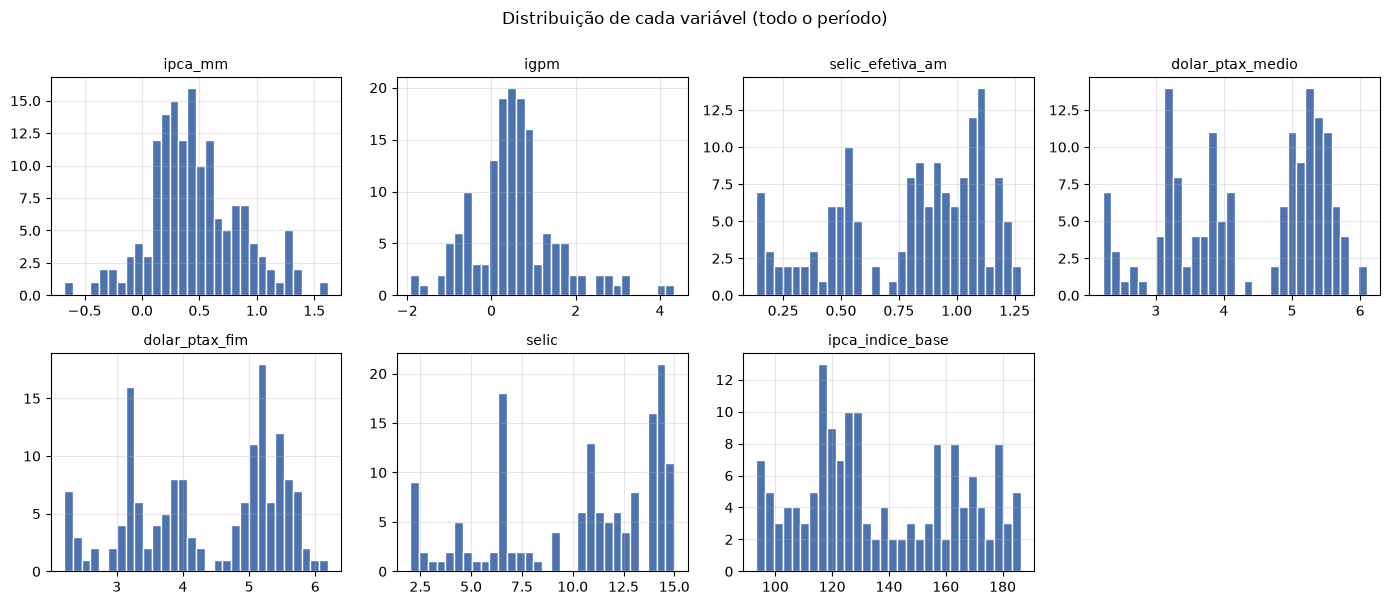

In [7]:
taxas = ["ipca_mm", "igpm", "selic_efetiva_am"]
niveis = ["dolar_ptax_medio", "dolar_ptax_fim", "selic", "ipca_indice_base"]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), taxas + niveis):
    ax.hist(df[col].astype("float64").dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribuição de cada variável (todo o período)", y=1.0)
fig.tight_layout()
plt.show()

Os histogramas das **taxas** mostram assimetria à direita: muitos meses de inflação baixa e umacauda de meses ruins. O `igpm` tem cauda bem mais longa que o `ipca_mm` — ele pesa preços noatacado e câmbio, então reage mais forte e mais cedo a choque cambial. É por isso que as duasséries não são substituíveis uma pela outra.Os **níveis** (dólar, Selic, índice) são multimodais: cada moda é um regime de política econômicadiferente, não ruído.

In [8]:
extremos = pd.concat(
    [
        df.nlargest(3, "ipca_mm")[["ano_mes", "ipca_mm", "igpm", "dolar_ptax_medio"]].assign(tipo="maior IPCA"),
        df.nsmallest(3, "ipca_mm")[["ano_mes", "ipca_mm", "igpm", "dolar_ptax_medio"]].assign(tipo="menor IPCA"),
        df.nlargest(3, "dolar_ptax_medio")[["ano_mes", "ipca_mm", "igpm", "dolar_ptax_medio"]].assign(tipo="maior dólar"),
    ]
)
extremos["ano_mes"] = extremos["ano_mes"].dt.strftime("%Y-%m")
extremos.set_index(["tipo", "ano_mes"]).round(3)

ipca_mm  igpm  dolar_ptax_medio
tipo        ano_mes                                 
maior IPCA  2022-03     1.62  1.74             4.968
            2020-12     1.35  0.96             5.146
            2015-03     1.32  0.98             3.139
menor IPCA  2022-07    -0.68  0.21             5.368
            2020-05    -0.38  0.28             5.643
            2022-08    -0.36  -0.7             5.143
maior dólar 2024-12     0.52  0.94             6.097
            2025-01     0.16  0.27             6.022
            2024-11     0.39   1.3             5.807

Há **deflação** no período (IPCA mensal negativo). Isso é real, não erro — e não é raro: a próximacélula conta quantos meses são. É a razão pela qual `ipca_indice_base` não é estritamentecrescente; o critério de aceite do T-013 foi escrito como "sem queda *sustentada*", não "sempresubindo".

In [9]:
neg = df.loc[df["ipca_mm"] < 0, ["ano_mes", "ipca_mm"]].copy()
neg["ano_mes"] = neg["ano_mes"].dt.strftime("%Y-%m")

idx = df["ipca_indice_base"].astype("float64")
recuo_max = float((idx / idx.cummax() - 1).min() * 100)

print(f"meses com IPCA negativo: {len(neg)} de {len(df)}")
print(f"recuo máximo do índice acumulado: {recuo_max:.2f}%")
neg.set_index("ano_mes").T

meses com IPCA negativo: 12 de 151
recuo máximo do índice acumulado: -1.32%


ano_mes,2017-06,2018-08,2018-11,2019-09,2020-04,2020-05,2022-07,2022-08,2022-09,2023-06,2024-08,2025-08
ipca_mm,-0.23,-0.09,-0.21,-0.04,-0.31,-0.38,-0.68,-0.36,-0.29,-0.08,-0.02,-0.11


---## 4. Comportamento no tempoÉ aqui que a natureza dos dados aparece: são séries com **tendência e regime**, não amostrasindependentes. Consequência prática para o modelo — split temporal, nunca aleatório.

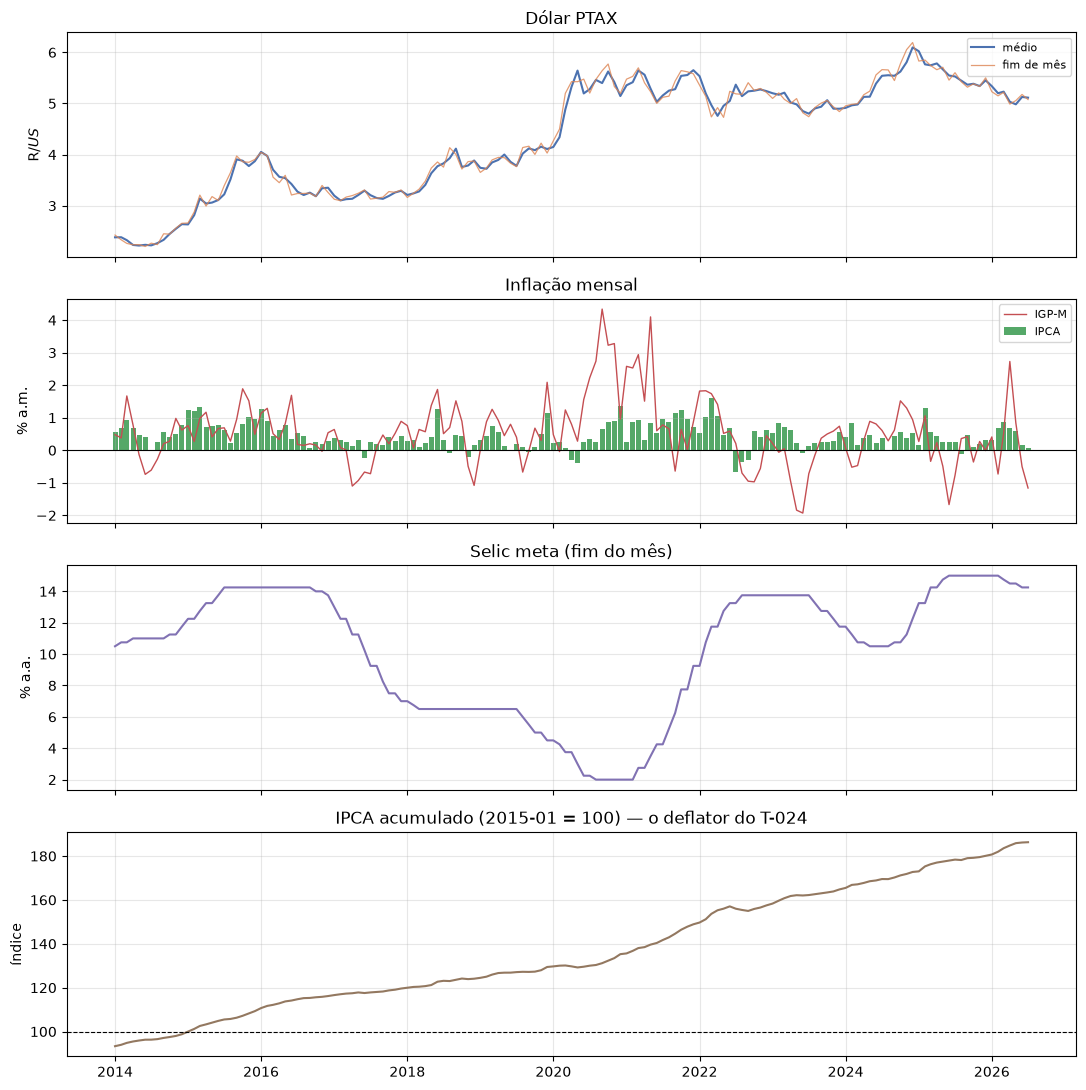

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

axes[0].plot(df["ano_mes"], df["dolar_ptax_medio"].astype("float64"), color="#4C72B0", label="médio")
axes[0].plot(df["ano_mes"], df["dolar_ptax_fim"].astype("float64"), color="#DD8452", lw=0.9, alpha=0.8, label="fim de mês")
axes[0].set_ylabel("R$/US$"); axes[0].set_title("Dólar PTAX"); axes[0].legend(fontsize=8)

axes[1].bar(df["ano_mes"], df["ipca_mm"].astype("float64"), width=25, color="#55A868", label="IPCA")
axes[1].plot(df["ano_mes"], df["igpm"].astype("float64"), color="#C44E52", lw=1, label="IGP-M")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("% a.m."); axes[1].set_title("Inflação mensal"); axes[1].legend(fontsize=8)

axes[2].plot(df["ano_mes"], df["selic"].astype("float64"), color="#8172B3")
axes[2].set_ylabel("% a.a."); axes[2].set_title("Selic meta (fim do mês)")

axes[3].plot(df["ano_mes"], df["ipca_indice_base"].astype("float64"), color="#937860")
axes[3].axhline(100, color="black", lw=0.8, ls="--")
axes[3].set_ylabel("índice"); axes[3].set_title("IPCA acumulado (2015-01 = 100) — o deflator do T-024")

fig.tight_layout()
plt.show()

In [11]:
acum = (
    df.assign(ano=df["ano_mes"].dt.year, f_ipca=1 + df["ipca_mm"] / 100, f_igpm=1 + df["igpm"] / 100)
    .groupby("ano")
    .agg(
        meses=("ano_mes", "size"),
        ipca_ano=("f_ipca", lambda s: (s.prod() - 1) * 100),
        igpm_ano=("f_igpm", lambda s: (s.prod() - 1) * 100),
        dolar_medio=("dolar_ptax_medio", "mean"),
        selic_fim=("selic", "last"),
    )
    .round(2)
)
acum

,meses,ipca_ano,igpm_ano,dolar_medio,selic_fim
ano,,,,,
2014,12,6.41,3.67,2.35,11.75
2015,12,10.67,10.54,3.33,14.25
2016,12,6.29,7.19,3.49,13.75
2017,12,2.95,-0.53,3.19,7.0
2018,12,3.75,7.55,3.65,6.5
2019,12,4.31,7.32,3.95,4.5
2020,12,4.52,23.14,5.16,2.0
2021,12,10.06,17.79,5.4,9.25
2022,12,5.78,5.46,5.16,13.75


A tabela anual resume o que os gráficos mostram: **2015 e 2021–2022 são os anos de choque**, comIPCA de dois dígitos e IGP-M ainda mais alto. Se o alvo do projeto for nominal, esses anos vãodominar o sinal — é exatamente o que a deflação pelo `ipca_indice_base` no T-024 existe para evitar.Repare também no descolamento entre os dois índices: em 2020 o IGP-M fecha em 23,1% contra 4,5% doIPCA, e em 2023 e 2025 ele fica **negativo** enquanto o IPCA segue positivo. Atacado e varejo nãose movem juntos — as duas variáveis carregam informação distinta, e nenhuma substitui a outra.

---## 5. Quanto essas variáveis se sobrepõemCorrelação alta entre features não invalida o dado, mas afeta a interpretação de coeficientes emmodelo linear e pode desestabilizar importâncias em modelo de árvore. Vale saber antes.

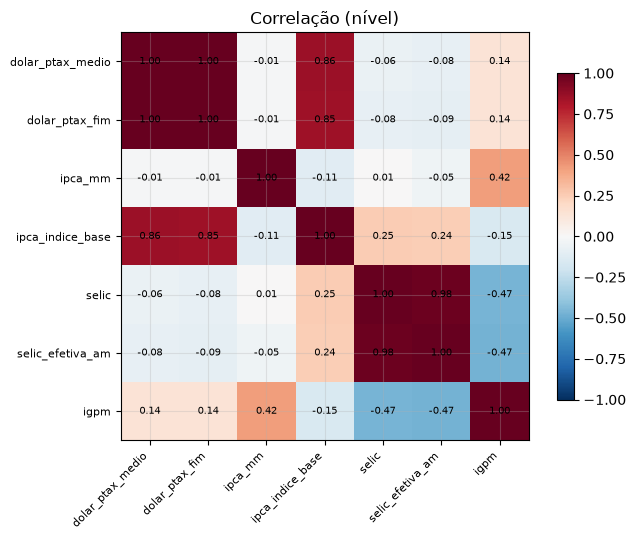

In [12]:
num = df.drop(columns="ano_mes").astype("float64")
corr = num.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlação (nível)")
fig.tight_layout()
plt.show()

In [13]:
pares = corr.stack().rename("corr").reset_index()
pares.columns = ["var_a", "var_b", "corr"]
pares = pares[pares["var_a"] < pares["var_b"]]
pares.reindex(pares["corr"].abs().sort_values(ascending=False).index).head(6).round(3).reset_index(drop=True)

,var_a,var_b,corr
0,dolar_ptax_fim,dolar_ptax_medio,0.996
1,selic,selic_efetiva_am,0.983
2,dolar_ptax_medio,ipca_indice_base,0.859
3,dolar_ptax_fim,ipca_indice_base,0.851
4,igpm,selic_efetiva_am,-0.474
5,igpm,selic,-0.467


Duas redundâncias são quase perfeitas e esperadas por construção:- `dolar_ptax_medio` × `dolar_ptax_fim` — mesma série, agregações diferentes. **Escolher uma.**- `selic` × `selic_efetiva_am` — a efetiva é a meta convertida para o mês. **Escolher uma.**`ipca_indice_base` correlaciona forte com quase tudo porque é monotônico no tempo: ele carregatendência, e qualquer série com tendência vai correlacionar com ele. Como feature é uma proxy de"que ano é" — o papel dele no projeto é ser **deflator**, não regressor.Nas taxas, `ipca_mm` × `igpm` fica em correlação moderada: andam juntos, mas longe de duplicados.

---## 6. Conferência contra valores publicadosUma verificação independente do QA do coletor: o IPCA acumulado por ano que sai deste arquivo temque bater com o que o IBGE divulgou.

In [14]:
OFICIAL_IPCA = {2015: 10.67, 2016: 6.29, 2017: 2.95, 2018: 3.75, 2019: 4.31,
                2020: 4.52, 2021: 10.06, 2022: 5.79, 2023: 4.62, 2024: 4.83}

conf = acum[["ipca_ano", "meses"]].join(pd.Series(OFICIAL_IPCA, name="ibge")).dropna(subset=["ibge"])
conf["dif_pp"] = (conf["ipca_ano"] - conf["ibge"]).round(3)
conf["ok"] = conf["dif_pp"].abs() <= 0.05
conf

,ipca_ano,meses,ibge,dif_pp,ok
ano,,,,,
2015,10.67,12,10.67,0.0,True
2016,6.29,12,6.29,0.0,True
2017,2.95,12,2.95,0.0,True
2018,3.75,12,3.75,0.0,True
2019,4.31,12,4.31,0.0,True
2020,4.52,12,4.52,0.0,True
2021,10.06,12,10.06,0.0,True
2022,5.78,12,5.79,-0.01,True
2023,4.62,12,4.62,0.0,True


In [15]:
print("todos os anos completos batem com o IBGE:", bool(conf["ok"].all()))

todos os anos completos batem com o IBGE: True


---## O que fica para a modelagem| Ponto | Consequência ||---|---|| Série mensal **nacional**, sem recorte por UF | Replicadas para todas as UFs no T-024; não explicam diferença *entre* estados || `dolar_ptax_medio` ≈ `dolar_ptax_fim` (corr. ~1) | Usar só uma — a média representa melhor o mês || `selic` ≈ `selic_efetiva_am` (corr. ~1, escalas diferentes) | Usar só uma; nunca comparar % a.a. com % a.m. sem converter || `ipca_indice_base` é acumulado e monotônico | Papel é **deflacionar o alvo**, não entrar como feature || Deflação em 12 dos 151 meses | `ipca_mm` negativo é dado válido, não outlier a limpar || Tendência e regime fortes | Split **temporal** na validação; split aleatório vaza futuro no treino || Tipos `Float64` (nullable) | Converter para `float64` antes do scikit-learn |